# **"EcoHome": Real Estate Price Predictor**

### **The Scenario**
You have been hired as a Data Scientist for **"EcoHome,"** a tech-enabled real estate firm. Your company wants to automate the valuation of properties to give sellers an instant price estimate.

Instead of sending an appraiser to every house, you must build an algorithm that predicts the **Price ($y$)** of a house based on its **Living Area ($x_1$)** and **Age ($x_2$)**.

---
# **Regularization (L1 & L2)**

We discussed **Overfitting**—when a model learns the "noise" in the training data rather than the actual pattern. To prevent this, we add a "penalty" term to our Loss Function to discourage the weights ($w$) from becoming too large.

### **The Two Types:**
1.  **L1 Regularization (Lasso):** Adds the *absolute value* of weights: $\lambda \sum |w_i|$
    * *Effect:* Can drive weights exactly to zero (Feature Selection).
2.  **L2 Regularization (Ridge):** Adds the *squared value* of weights: $\lambda \sum w_i^2$
    * *Effect:* Shrinks weights towards zero but rarely hits exactly zero.

where $\lambda$ (lambda) is a hyperparameter that controls how strictly we penalize the model.



### **Knowledge Check: Regularization Theory**

**Question 1:**
You are working on the "EcoHome" dataset, but you have thousands of potential features (number of windows, color of door, type of faucet, etc.). You suspect most of these features are irrelevant and you want a model that automatically selects only the important ones by setting the coefficients of useless features to exactly **zero**.

Which technique should you use?

A) Ridge Regression (L2)

B) Lasso Regression (L1)

C) Standard Linear Regression (No Regularization)

D) Increase the Learning Rate



**Answer:** B) Lasso Regression (L1)

explanation:Lasso Regression (L1) can drive the coefficients of irrelevant features to exactly zero, effectively performing feature selection.

Adds the *absolute value* of weights: $\lambda \sum |w_i|$ 

**Question 2:**
In **L2 (Ridge) Regression**, we minimize the cost function: $J(w) = MSE(w) + \lambda \sum w_i^2$.
What happens if you set the regularization parameter $\lambda$ to be extremely large (e.g., $\lambda \to \infty$)?

A) The model will overfit the data perfectly (Low Bias, High Variance).

B) The weights $w$ will explode to infinity.

C) The weights $w$ will be forced towards zero, resulting in a flat horizontal line (High Bias, Low Variance).

D) The model converts into a Neural Network.


**Answer:** C) The weights $w$ will be forced towards zero, resulting in a flat horizontal line (High Bias, Low Variance).

explaination: A very large $\lambda$ heavily penalizes large weights, pushing them towards zero. This leads to a model that is too simple (high bias) and does not capture the underlying patterns in the data.

**The Scenario:**
The "EcoHome" team wants to ensure your model is robust. They want you to implement **Ridge Regression** (L2 Regularization).

**Mathematical Refresher:**
For Ridge Regression, the gradient of the loss function changes. We must add the derivative of the penalty term to our update rule.
* **MSE Gradient:** $\nabla_{MSE} = \frac{2}{N} X^T (Xw - y)$
* **L2 Penalty Gradient:** $\frac{\partial}{\partial w} (\lambda w^2) = 2 \lambda w$

**Question 3:**
Modify the code below to include the **L2 penalty term** in the gradient calculation.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
N = 100
# Feature: Size (sq ft) centered/scaled
X_size = 2 * np.random.rand(N, 1)
# True Relation: Price = 4 + 3 * Size + Noise
y = 4 + 3 * X_size + np.random.randn(N, 1)

# Add Bias Term (Column of 1s) to X
X_b = np.c_[np.ones((N, 1)), X_size]

In [12]:
# --- STUDENT IMPLEMENTATION: L2 RIDGE REGRESSION ---
def ridge_gradient_descent(X, y, w_init, learning_rate=0.01, lambda_reg=1.0, n_iterations=100):
    m = len(X)
    w = w_init.copy() # Start with provided initialization

    for iteration in range(n_iterations):
        # 1. Calculate Standard MSE Gradient
        gradients_mse = 2/m * X.T.dot(X.dot(w) - y)

        # 2. TODO: Add the L2 Regularization Term
        # HINT: The derivative of (lambda * w^2) is (2 * lambda * w)
        # MODIFY THE LINE BELOW:

        gradients_total = gradients_mse + 2 * lambda_reg * w # Add gradient for regularization here

        # 3. Update Weights
        w = w - learning_rate * gradients_total

    return w

# --- TEST YOUR CODE ---
# We run standard GD and Ridge GD. Ridge weights should be smaller (closer to 0).
w_init = np.array([[4.0], [4.0]]) # Initialize with large weights
w_standard = ridge_gradient_descent(X_b, y, w_init, lambda_reg=0) # Lambda=0 is just Standard Linear Regression
w_ridge    = ridge_gradient_descent(X_b, y, w_init, lambda_reg=10) # High Regularization

print(f"Standard Slope Weight: {w_standard[1][0]:.4f}")
print(f"Ridge (L2) Slope Weight:   {w_ridge[1][0]:.4f} (Should be smaller/shrunk)")

Standard Slope Weight: 3.2382
Ridge (L2) Slope Weight:   0.6097 (Should be smaller/shrunk)


### **Visualizing the Descent**

---


It can be hard to visualize Gradient Descent in high dimensions. Let's simplify it to 1 dimension to see exactly how the algorithm "rolls down the hill" to find the minimum.

**Setup:**
* **X-axis:** The parameter value ($\theta$)
* **Y-axis:** The Loss ($J(\theta)$)
* **Loss Function:** A simple quadratic bowl: $J(\theta) = \theta^2$

Starting at x=-4.0


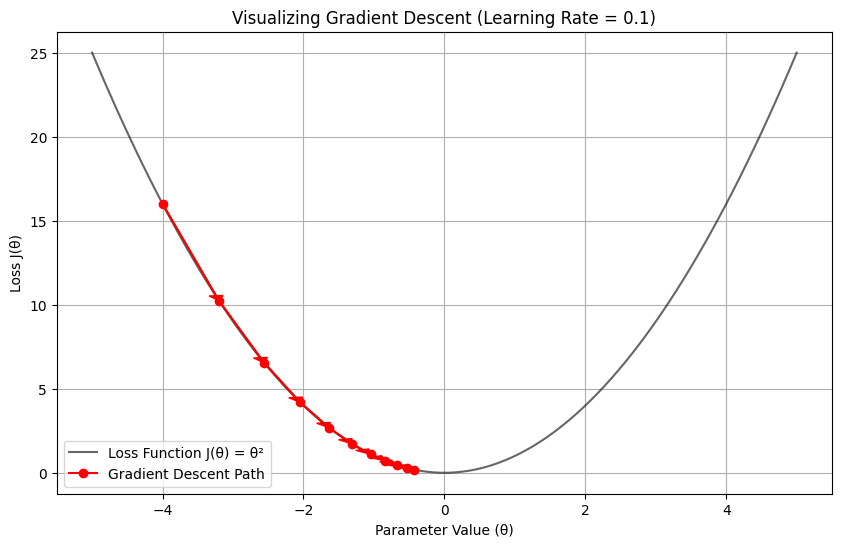

Starting at x=-4.0


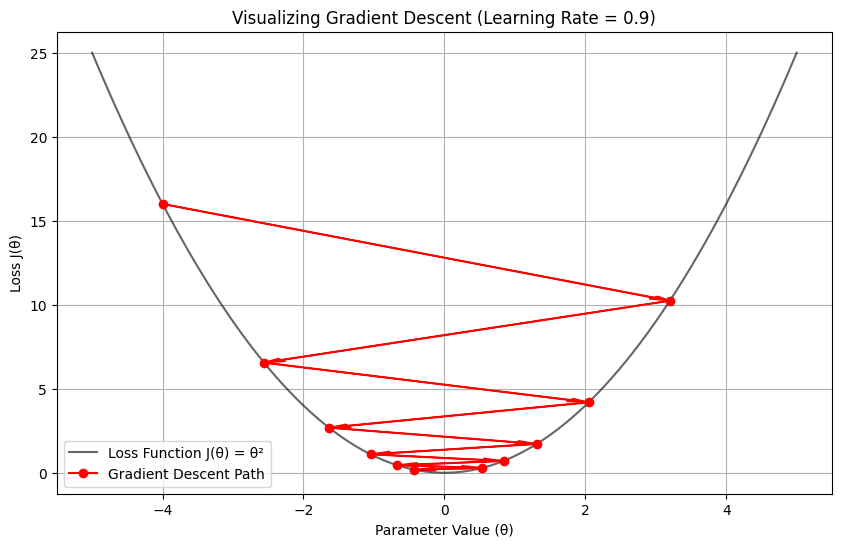

Starting at x=-4.0


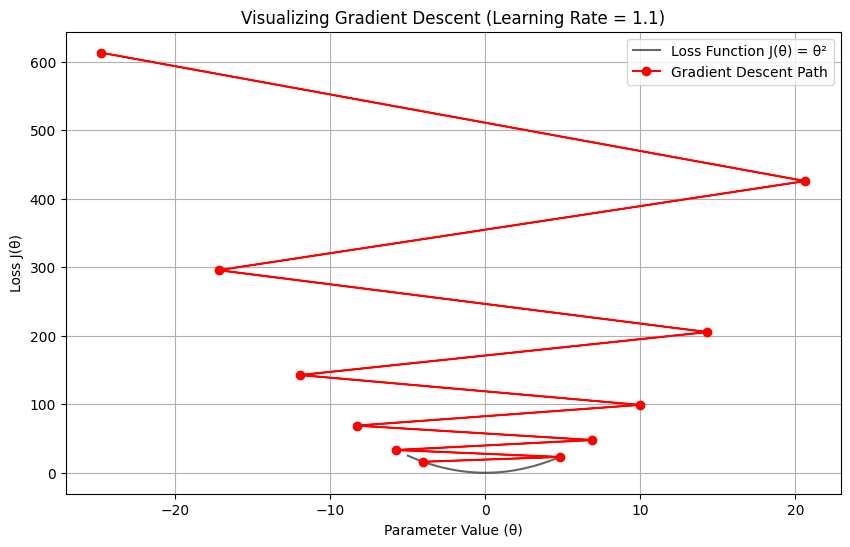

In [13]:
def visualize_gradient_descent(learning_rate=0.1, n_steps=10):
    """
    Visualizes gradient descent on a simple quadratic loss function J(x) = x^2
    """
    # 1. Setup the "Loss Surface" (The Bowl)
    x_values = np.linspace(-5, 5, 100)
    y_values = x_values**2

    # 2. Run Gradient Descent
    current_x = -4.0  # Start at x = -4
    history_x = [current_x]
    history_y = [current_x**2]

    print(f"Starting at x={current_x}")
    for _ in range(n_steps):
        # Gradient of x^2 is 2x
        gradient = 2 * current_x
        current_x = current_x - learning_rate * gradient

        history_x.append(current_x)
        history_y.append(current_x**2)

    # 3. Plotting
    plt.figure(figsize=(10, 6))

    # Plot the Loss Surface
    plt.plot(x_values, y_values, 'k-', alpha=0.6, label='Loss Function J(θ) = θ²')

    # Plot the Steps
    history_x = np.array(history_x)
    history_y = np.array(history_y)
    plt.plot(history_x, history_y, 'ro-', label='Gradient Descent Path')

    # Arrows to show direction
    for i in range(len(history_x)-1):
        plt.arrow(history_x[i], history_y[i],
                  history_x[i+1]-history_x[i], history_y[i+1]-history_y[i],
                  head_width=0.2, color='red', length_includes_head=True)

    plt.title(f"Visualizing Gradient Descent (Learning Rate = {learning_rate})")
    plt.xlabel("Parameter Value (θ)")
    plt.ylabel("Loss J(θ)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Try changing the learning rate!
# 0.1 = Smooth convergence
# 0.9 = Zig-zag convergence
# 1.1 = Divergence (Explosion)
visualize_gradient_descent(learning_rate=0.1)
visualize_gradient_descent(learning_rate=0.9)
visualize_gradient_descent(learning_rate=1.1)